# **Problem Statement:**

Imagine you are a crciket coach of Indian Cricekt Team and you have stats of 100 Players. You want to group players with similar abilities so that you can select players for different match staretigies.

Our goal is to group players with similar performance characteristics into clusters.

In [1]:
#Import Libraires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the Dataset
df=pd.read_csv('KMean_Cricket_dataset.csv',encoding='latin1')  #uses utf-8,latin1,ISO-8859-1,cp1252

In [3]:
df

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15


In [4]:
#E.D.A
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     str    
 1   Span    79 non-null     str    
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     str    
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 8.2 KB


In [5]:
#We will  divide the span column into two other columns start and end
df[['start','end']]=df['Span'].str.split('-',expand=True)

In [6]:
df

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3,1975,1991
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6,2002,2015
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7,2001,2011
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     str    
 1   Span    79 non-null     str    
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     str    
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
 13  start   79 non-null     str    
 14  end     79 non-null     str    
dtypes: float64(2), int64(8), str(5)
memory usage: 9.4 KB


In [8]:
#Convert the Datatype of Start and End into integer
df['start']=df['start'].astype(int)
df['end']=df['end'].astype(int)

In [9]:
#Create a EXP column by subtracting the end year from the start year
df['EXP']=df['end']-df['start']

In [10]:
df

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,EXP
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3,1975,1991,16
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6,2002,2015,13
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7,2001,2011,10
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009,11


In [11]:
#Since we have the exp column now we will drop start,end and span
# df.drop(columns=['Span','start','end'],axis=1,inplace=True)

In [12]:
df.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,EXP
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     str    
 1   Span    79 non-null     str    
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     str    
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
 13  start   79 non-null     int64  
 14  end     79 non-null     int64  
 15  EXP     79 non-null     int64  
dtypes: float64(2), int64(11), str(3)
memory usage: 10.0 KB


In [14]:
df['HS']=df['HS'].str.replace('*','')

In [15]:
df['HS']

0     200
1     169
2     164
3     189
4     144
     ... 
74    133
75     96
76    120
77    156
78    112
Name: HS, Length: 79, dtype: str

In [16]:
df['HS']=df['HS'].astype(int)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     str    
 1   Span    79 non-null     str    
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     int64  
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
 13  start   79 non-null     int64  
 14  end     79 non-null     int64  
 15  EXP     79 non-null     int64  
dtypes: float64(2), int64(12), str(2)
memory usage: 10.0 KB


In [18]:
df.isnull().sum()

Player    0
Span      0
Mat       0
Inns      0
NO        0
Runs      0
HS        0
Ave       0
BF        0
SR        0
100       0
50        0
0         0
start     0
end       0
EXP       0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
#Outliers--Homeworkk

In [21]:
#We will create a copy of the whole dataset
df_copy=df.copy()

In [22]:
df_copy

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,EXP
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133,45.03,7908,64.92,11,31,3,1975,1991,16
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96,43.40,6945,73.75,0,42,6,2002,2015,13
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120,35.36,6614,76.98,5,26,7,2001,2011,10
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009,11


In [23]:
df

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,EXP
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133,45.03,7908,64.92,11,31,3,1975,1991,16
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96,43.40,6945,73.75,0,42,6,2002,2015,13
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120,35.36,6614,76.98,5,26,7,2001,2011,10
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009,11


In [24]:
df_copy.drop(['Span', 'HS'],axis=1,inplace=True)

In [25]:
df_copy

,Player,Mat,Inns,NO,Runs,Ave,BF,SR,100,50,0,start,end,EXP
0,SR Tendulkar (INDIA),463,452,41,18426,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),375,365,39,13704,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),445,433,18,13430,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,33.37,16020,78.96,19,77,28,1998,2015,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),128,127,13,5134,45.03,7908,64.92,11,31,3,1975,1991,16
75,Misbah-ul-Haq (PAK),162,149,31,5122,43.40,6945,73.75,0,42,6,2002,2015,13
76,PD Collingwood (ENG),197,181,37,5092,35.36,6614,76.98,5,26,7,2001,2011,10
77,A Symonds (AUS),198,161,33,5088,39.75,5504,92.44,6,30,15,1998,2009,11


In [26]:
df

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,EXP
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133,45.03,7908,64.92,11,31,3,1975,1991,16
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96,43.40,6945,73.75,0,42,6,2002,2015,13
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120,35.36,6614,76.98,5,26,7,2001,2011,10
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009,11


# Standarzation:

Standardization is a technique which is used to sacle the numerical data.

In [27]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler=StandardScaler()

In [51]:
# Select only numeric columns
df_copy_numeric = df_copy.select_dtypes(include=['number'])
df_scaled = scaler.fit_transform(df_copy_numeric)

In [53]:
np.set_printoptions(suppress=True, threshold=np.inf, linewidth=np.inf)
df_scaled

array([[ 2.95528204,  3.1693334 ,  0.76496275,  4.26232808,  1.07229395,  3.68121424,  0.70315153,  4.65672622,  3.0500572 ,  1.14583653, -0.67030765,  0.46828112,  2.81278702],
       [ 2.15517925,  2.13891509,  0.76496275,  2.60911662,  0.58772461,  2.63538469, -0.0441395 ,  1.67188751,  2.86541772,  0.29667062,  0.62126074,  0.86464763,  0.38093832],
       [ 1.76190839,  1.92424461,  0.6253968 ,  2.40009894,  0.59622582,  2.31965067,  0.1109969 ,  2.29372891,  2.1884063 ,  1.14583653,  0.0341842 ,  0.46828112,  0.9889005 ],
       [ 2.71118288,  2.89741746, -0.8400457 ,  2.29204075, -1.04790945,  1.58829472,  1.20709133,  2.04499235,  1.3267554 ,  3.52350108, -0.67030765,  0.33615894,  2.50880593],
       [ 2.75186607,  2.68274698,  0.6253968 ,  1.98442984, -0.87618487,  1.99635416, -0.03399986,  0.92567783,  1.88067384,  2.50450199,  0.38643013,  0.86464763,  0.9889005 ],
       [ 1.80259158,  1.70957413,  1.60235846,  1.62515607,  0.16946476,  1.93081256, -0.51259058, -0.19363669

In [46]:
df_scaled = pd.DataFrame(df_scaled, columns=df_copy_numeric.columns)

In [54]:
df_scaled

array([[ 2.95528204,  3.1693334 ,  0.76496275,  4.26232808,  1.07229395,  3.68121424,  0.70315153,  4.65672622,  3.0500572 ,  1.14583653, -0.67030765,  0.46828112,  2.81278702],
       [ 2.15517925,  2.13891509,  0.76496275,  2.60911662,  0.58772461,  2.63538469, -0.0441395 ,  1.67188751,  2.86541772,  0.29667062,  0.62126074,  0.86464763,  0.38093832],
       [ 1.76190839,  1.92424461,  0.6253968 ,  2.40009894,  0.59622582,  2.31965067,  0.1109969 ,  2.29372891,  2.1884063 ,  1.14583653,  0.0341842 ,  0.46828112,  0.9889005 ],
       [ 2.71118288,  2.89741746, -0.8400457 ,  2.29204075, -1.04790945,  1.58829472,  1.20709133,  2.04499235,  1.3267554 ,  3.52350108, -0.67030765,  0.33615894,  2.50880593],
       [ 2.75186607,  2.68274698,  0.6253968 ,  1.98442984, -0.87618487,  1.99635416, -0.03399986,  0.92567783,  1.88067384,  2.50450199,  0.38643013,  0.86464763,  0.9889005 ],
       [ 1.80259158,  1.70957413,  1.60235846,  1.62515607,  0.16946476,  1.93081256, -0.51259058, -0.19363669

# **Model Building:**

In [55]:
from sklearn.cluster import KMeans

In [ ]:
'''
How to chose the number of k values(number of clusters):

If you have a small dataset:for small dataset you can try the kvalue from 1 to 10 or 15.

If you have a big dataset: For large datasets you can try the k values around (30, n/10)   n=no of rows,
'''

'\nHow to chose the number of k values(number of clusters):\n\nIf you have a small dataset:for small dataset you can try the kvalue from 1 to 10 or 15.\n\nIf you have a big dataset: For large datasets you can try the k values around (30, n/10)   n=no of rows,\n'

In [56]:
k_values = [2,3,4,5,6,7,8,9]

In [57]:
wcss = []
for i in k_values:
    km = KMeans(n_clusters=i,random_state=42)
    km.fit(df_scaled)
    wcss.append(km.inertia_)

In [58]:
wcss

[724.696336730937,
 583.2820539110879,
 499.7503157883722,
 484.72753409776897,
 414.7376138273817,
 384.95417688363943,
 389.86436127200255,
 353.05962090027464]

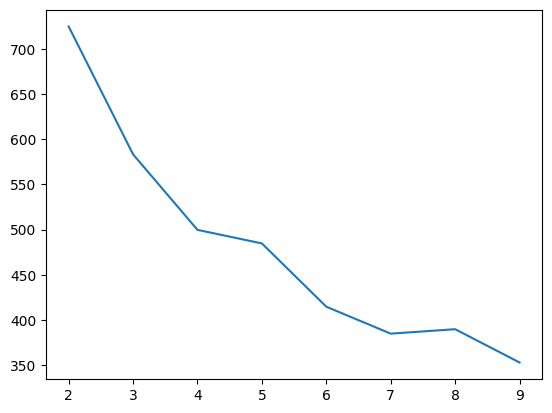

In [59]:
plt.plot(k_values,wcss)

In [ ]:
# Range of k-values-4,5,6,7,8,9

# **Shiloutte Score:**
Silhouttee Score(Metric) : It is a metric used to evaluate how good the clustering is.

or

How well each data point fits inside its own cluster and how far it is from other clusters

For Every k _value it will give a score which is between 1 to -1

Near +1 Excellent clusterig

Around 0 Overlapping clusters

Near -1 Incorrect clustering

The silhouette score for a point is calculated as:

\[ s = \frac{b - a}{\max(a, b)} \]

where:
- \(a\) = average intra-cluster distance
- \(b\) = average nearest-cluster distance

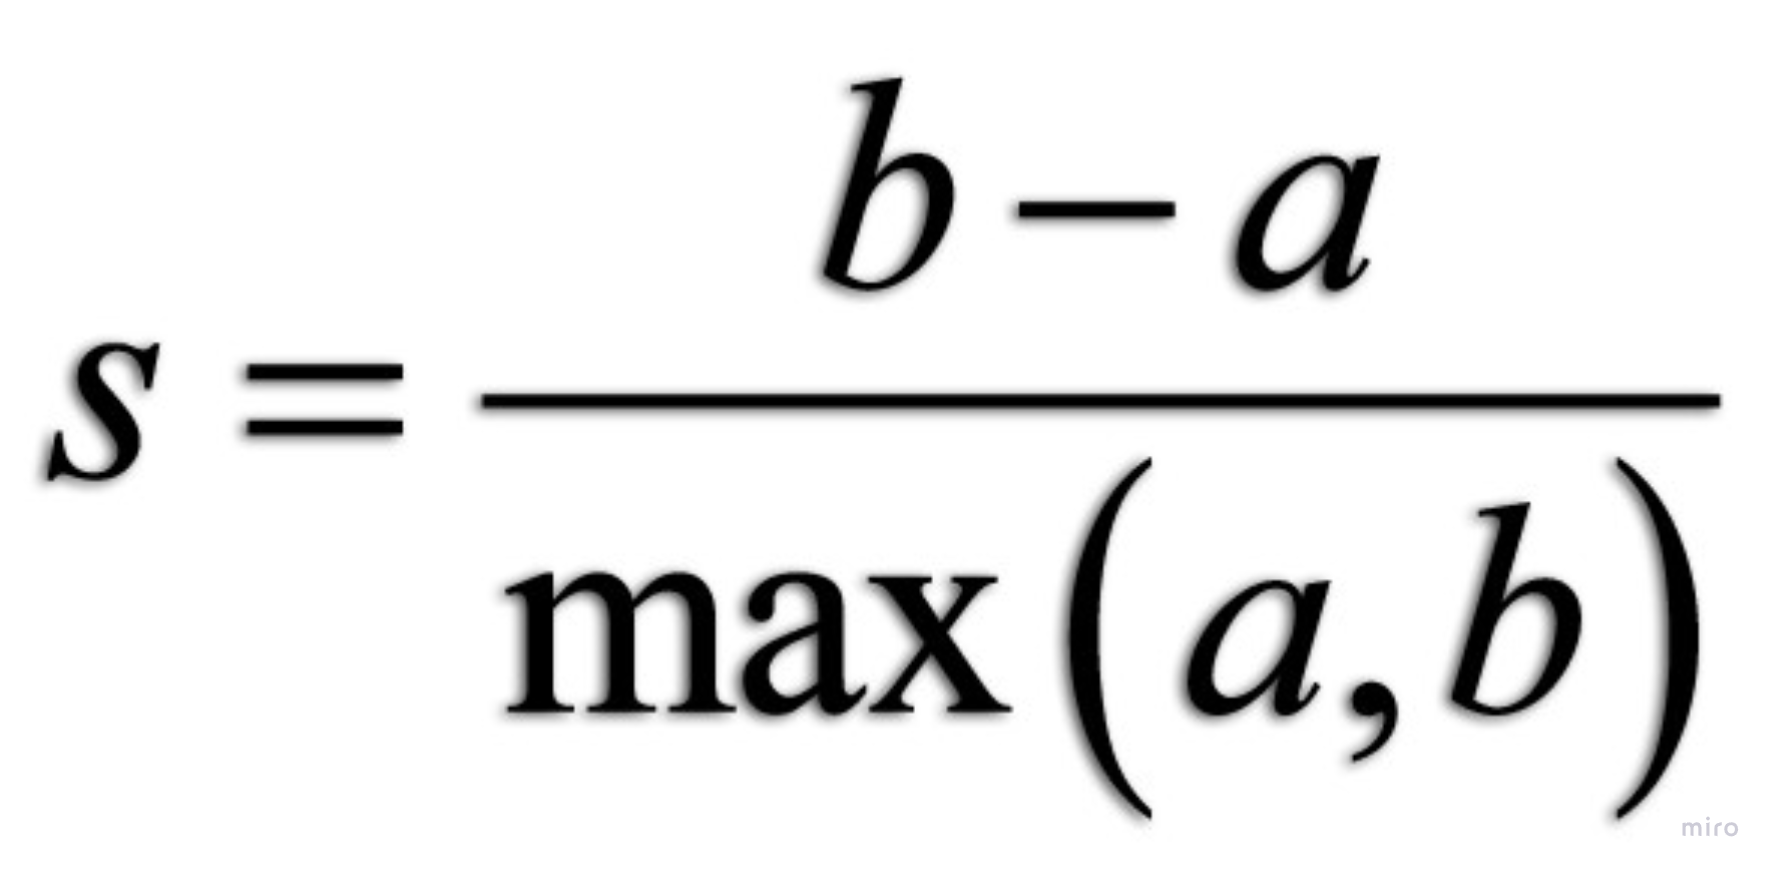

a= Intra-Cluster Distance

Average distance of a point from other points in the same cluster

b= Inter-Cluster Distance

Average Distance from points in the Nearest other cluster.

Case 1: Good Cluster

a=2, b=10

s=10-2/max(2,10)

=8/10 =0.8 (closer to 1)

Case 2: Overlapping Cluster

a=5, b=5

s=5-5/max(5,5) s=0

Case 3: Wrong Clustering

a=8, b=3

s=8-3/max(3,8) =5/8 =0.6

In [60]:
from sklearn.metrics import silhouette_score
k_values=range(2,10)
score = []

for i in k_values:
    km = KMeans(n_clusters=i,random_state=42)
    km.fit(df_scaled)

    silhouette_avg = silhouette_score(df_scaled, km.labels_)
    score.append(silhouette_avg)

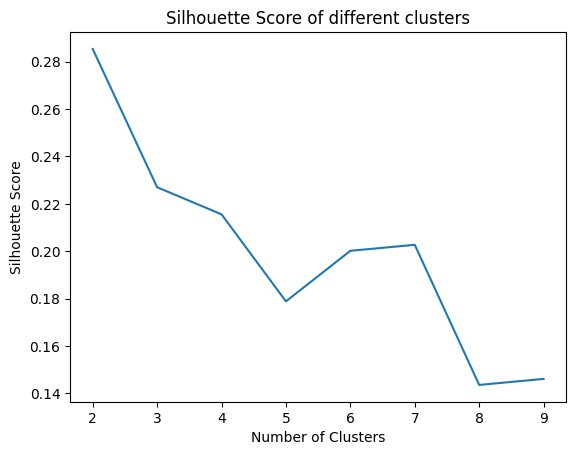

In [61]:
plt.plot(k_values,score)
plt.title("Silhouette Score of different clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
# The optimal value for k is 4.

In [62]:
kmeans = KMeans(n_clusters=4,random_state=42)

In [63]:
kmeans.fit(df_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [64]:
df['ClusterID'] = kmeans.labels_

In [65]:
df

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,EXP,ClusterID
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012,23,2
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15,2
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17,2
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22,2
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133,45.03,7908,64.92,11,31,3,1975,1991,16,1
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96,43.40,6945,73.75,0,42,6,2002,2015,13,3
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120,35.36,6614,76.98,5,26,7,2001,2011,10,3
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009,11,3


In [66]:
group1 = df[df['ClusterID']==1]
group1

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,EXP,ClusterID
21,DL Haynes (WI),1978-1994,238,237,28,8648,152,41.37,13707,63.09,17,57,13,1978,1994,16,1
30,SR Waugh (AUS),1986-2002,325,288,58,7569,120,32.90,9971,75.91,3,45,15,1986,2002,16,1
31,A Ranatunga (SL),1982-1999,269,255,47,7456,131,35.84,9571,77.90,4,49,18,1982,1999,17,1
32,Javed Miandad (PAK),1975-1996,233,218,41,7381,119,41.70,11014,67.01,8,50,8,1975,1996,21,1
35,Saleem Malik (PAK),1982-1999,283,256,38,7170,102,32.88,9383,76.41,5,47,19,1982,1999,17,1
38,MG Bevan (AUS),1994-2004,232,196,67,6912,108,53.58,9320,74.16,6,46,5,1994,2004,10,1
39,G Kirsten (SA),1993-2003,185,185,19,6798,188,40.95,9436,72.04,13,45,11,1993,2003,10,1
40,A Flower (ZIM),1992-2003,213,208,16,6786,145,35.34,9097,74.59,4,55,13,1992,2003,11,1
42,IVA Richards (WI),1975-1991,187,167,24,6721,189,47.00,7451,90.20,11,45,7,1975,1991,16,1
43,GW Flower (ZIM),1992-2010,221,214,18,6571,142,33.52,9723,67.58,6,40,18,1992,2010,18,1


In [67]:
group2 = df[df['ClusterID']==2]
group2

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,EXP,ClusterID
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012,23,2
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15,2
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17,2
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22,2
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17,2
5,Inzamam-ul-Haq (Asia/PAK),1991-2007,378,350,53,11739,137,39.52,15812,74.24,10,83,20,1991,2007,16,2
6,JH Kallis (Afr/ICC/SA),1996-2014,328,314,53,11579,139,44.36,15885,72.89,17,86,17,1996,2014,18,2


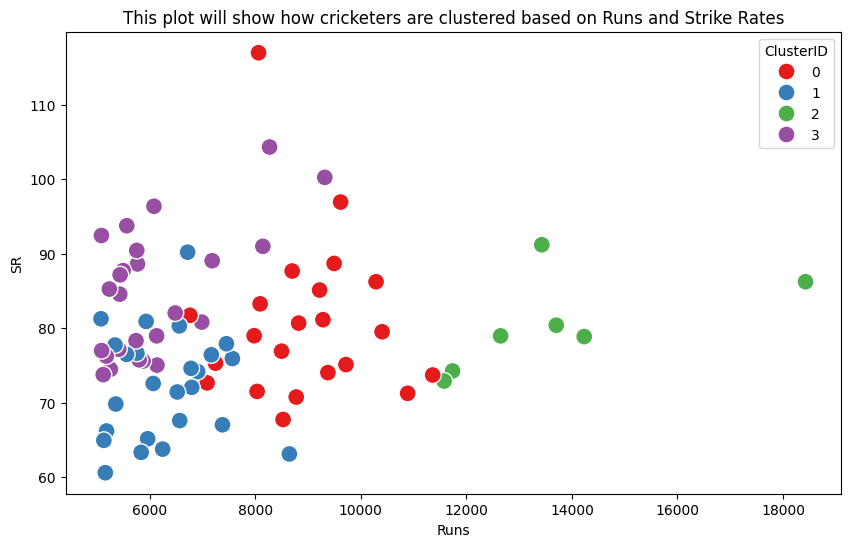

In [68]:
# plot the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Runs',y='SR',hue='ClusterID',palette='Set1',s=150)
plt.title('This plot will show how cricketers are clustered based on Runs and Strike Rates')
plt.show()

In [ ]:
!pip install plotly


In [69]:
import plotly.express as px

In [71]:
#Create a 3d scatter plot
fig=px.scatter_3d(df,x='Runs',y='Ave',z='SR',color='ClusterID',hover_data='Player',title='3d Scatter Plot of cricketer')

#Change layout
fig.update_layout(scene=dict(xaxis_title='Runs',yaxis_title='Average',zaxis_title='Strike Rate'),width=800,height=600)

fig.show()